# Bootstrap Model Fitting Results - Raincloud Plots

Visualization of recovered parameters across bootstrap iterations for each monkey and model.

## Import Required Libraries

Import pandas, numpy, matplotlib, and seaborn. Set plotting style and configure figure sizes.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10

# Configure paths
from popy.config import PROJECT_PATH_LOCAL, COLORS
results_dir = os.path.join(PROJECT_PATH_LOCAL, "notebooks", "behav_modeling", "results", "bootstrap")

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-vo0ngtxa because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Load Results Data

Load the recovered parameters from saved results files (CSV) into DataFrames.

In [2]:
# Load results from CSV files for each monkey
monkeys = ["ka", "po"]
results_dfs = {}

for monkey in monkeys:
    csv_path = os.path.join(results_dir, f"{monkey}_bootstrap_all_models.csv")
    if os.path.exists(csv_path):
        results_dfs[monkey] = pd.read_csv(csv_path)
        print(f"Loaded {monkey.upper()}: {len(results_dfs[monkey])} rows")
        print(f"Columns: {results_dfs[monkey].columns.tolist()}\n")
    else:
        print(f"Warning: File not found for {monkey} at {csv_path}")

# Combine results from both monkeys
if results_dfs:
    combined_df = pd.concat(
        [df.assign(monkey=monkey) for monkey, df in results_dfs.items()],
        ignore_index=True
    )
    print(f"Combined data shape: {combined_df.shape}")
    print(f"Models in data: {combined_df['model'].unique()}")
else:
    print("No results files found!")

Loaded KA: 300 rows
Columns: ['model', 'bootstrap_idx', 'alpha', 'beta', 'V0', 'best_ll', 'bic', 'lpt', 'fit_time_sec', 'stickiness_bias']

Loaded PO: 300 rows
Columns: ['model', 'bootstrap_idx', 'alpha', 'beta', 'V0', 'best_ll', 'bic', 'lpt', 'fit_time_sec', 'stickiness_bias']

Combined data shape: (600, 11)
Models in data: ['Foraging' 'Inferential RL - stickiness' 'Standard RL - stickiness']


## Prepare Data for Plotting

Organize the data into long format with columns for monkey, parameter name, parameter value, and model name.

In [3]:
# Identify parameter columns (exclude metadata columns)
metadata_cols = {"model", "bootstrap_idx", "monkey", "best_ll", "bic", "lpt", "fit_time_sec"}
param_cols = [col for col in combined_df.columns if col not in metadata_cols]

print(f"Parameter columns identified: {param_cols}")

# Build summary DataFrame (mean, std, and percentile-based 95% CI) before plotting
summary_rows = []
for (model, monkey), group in combined_df.groupby(["model", "monkey"]):
    for param in param_cols:
        values = group[param].dropna()
        if values.empty:
            continue
        summary_rows.append(
            {
                "model": model,
                "monkey": monkey.upper(),
                "parameter": param,
                "n": len(values),
                "mean": values.mean(),
                "std": values.std(ddof=1),
                "ci95_low": values.quantile(0.025),
                "ci95_high": values.quantile(0.975),
            }
        )

parameter_summary_df = pd.DataFrame(summary_rows)

# Add mean LPT and its 95% CI per model/monkey
lpt_rows = []
for (model, monkey), group in combined_df.groupby(["model", "monkey"]):
    lpt_values = group["lpt"].dropna()
    if lpt_values.empty:
        continue
    lpt_rows.append(
        {
            "model": model,
            "monkey": monkey.upper(),
            "mean_lpt": lpt_values.mean(),
            "lpt_ci95_low": lpt_values.quantile(0.025),
            "lpt_ci95_high": lpt_values.quantile(0.975),
            "n": len(lpt_values),
        }
    )

lpt_summary_df = pd.DataFrame(lpt_rows)

print("\nParameter summary DataFrame preview:")
display(parameter_summary_df.head())
print("\nLPT summary DataFrame:")
display(lpt_summary_df)

# Convert to long format for plotting (kept for raincloud visualizations)
plot_data = []
for model in combined_df["model"].unique():
    model_data = combined_df[combined_df["model"] == model].copy()

    for param in param_cols:
        if param in model_data.columns:
            for monkey in ["ka", "po"]:
                monkey_data = model_data[model_data["monkey"] == monkey]
                for val in monkey_data[param].dropna():
                    plot_data.append(
                        {
                            "model": model,
                            "parameter": param,
                            "value": val,
                            "monkey": monkey.upper(),
                        }
                    )

plot_df = pd.DataFrame(plot_data)

# Save back to the bootstrap folder
plot_csv_path = os.path.join(results_dir, "combined_bootstrap_plot_data.csv")
plot_df.to_csv(plot_csv_path, index=False)

print(f"\nPlot data shape: {plot_df.shape}")
print(f"Models: {plot_df['model'].unique()}")
print(f"Parameters: {plot_df['parameter'].unique()}")
print(f"Monkeys: {plot_df['monkey'].unique()}")

Parameter columns identified: ['alpha', 'beta', 'V0', 'stickiness_bias']

Parameter summary DataFrame preview:


,model,monkey,parameter,n,mean,std,ci95_low,ci95_high
0,Foraging,KA,alpha,100,0.407116,0.013036,0.386740,0.425003
1,Foraging,KA,beta,100,10.967747,0.270308,10.644119,11.421885
2,Foraging,KA,V0,100,0.123501,0.005158,0.114858,0.131583
3,Foraging,PO,alpha,100,0.296025,0.013165,0.262504,0.312027
4,Foraging,PO,beta,100,6.969627,0.186733,6.771202,7.251742



LPT summary DataFrame:


,model,monkey,mean_lpt,lpt_ci95_low,lpt_ci95_high,n
0,Foraging,KA,0.795777,0.787051,0.804275,100
1,Foraging,PO,0.597649,0.577576,0.607257,100
2,Inferential RL - stickiness,KA,0.758011,0.747755,0.766802,100
3,Inferential RL - stickiness,PO,0.564360,0.555147,0.578681,100
4,Standard RL - stickiness,KA,0.745902,0.729260,0.753034,100
5,Standard RL - stickiness,PO,0.547889,0.539142,0.564963,100



Plot data shape: (1800, 4)
Models: ['Foraging' 'Inferential RL - stickiness' 'Standard RL - stickiness']
Parameters: ['alpha' 'beta' 'V0' 'stickiness_bias']
Monkeys: ['KA' 'PO']


## Create Raincloud Plots for Each Parameter

Use Seaborn to create raincloud plots combining stripplot for scatter, boxplot for box plot, and violinplot with cut=0 for the half violin.

In [4]:
def create_raincloud_plot(data, ax, parameter_name, color_dict):
    """
    Create a raincloud plot with scatter on left, half-violin on right, boxplot in middle.

    Parameters
    ----------
    data : pd.DataFrame
        Data with columns: 'monkey', 'value'
    ax : matplotlib.axes.Axes
        Axes to plot on
    parameter_name : str
        Name of the parameter for the title
    color_dict : dict
        Dictionary mapping monkey names to colors
    """
    from scipy import stats

    colors = [color_dict.get("KA"), color_dict.get("PO")]

    # Scatter plot on the left
    for idx, monkey in enumerate(["KA", "PO"]):
        monkey_data = data[data["monkey"] == monkey]["value"].dropna().values
        if len(monkey_data) > 0:
            x_vals = np.random.normal(idx - 0.25, 0.02, size=len(monkey_data))
            ax.scatter(x_vals, monkey_data, color="black", alpha=0.4, s=15)

    # Half violin on the right (showing only right half of distribution)
    for idx, monkey in enumerate(["KA", "PO"]):
        monkey_data = data[data["monkey"] == monkey]["value"].dropna().values
        if len(monkey_data) > 1:
            # Compute KDE
            kde = stats.gaussian_kde(monkey_data)
            y_min_extended = monkey_data.min() - 0.5 * (monkey_data.max() - monkey_data.min())
            y_max_extended = monkey_data.max() + 0.5 * (monkey_data.max() - monkey_data.min())
            y_range = np.linspace(y_min_extended, y_max_extended, 200)
            density = kde(y_range)

            # Normalize density to width (right half only)
            density_normalized = density / density.max() * 0.2

            # Fill between for right half of violin
            x_base = idx + 0.15
            ax.fill_betweenx(
                y_range,
                x_base,
                x_base + density_normalized,
                color=colors[idx],
                alpha=0.3,
                edgecolor="black",
                linewidth=0.8,
            )

    # Boxplot in the middle
    sns.boxplot(
        data=data,
        x="monkey",
        y="value",
        ax=ax,
        width=0.1,
        hue="monkey",
        palette=color_dict,
        showfliers=True,
        whis=(0, 100),
        order=["KA", "PO"],
        legend=False,
    )

    # Overlay bootstrap summary lines: mean (solid red) and 95% CI (dashed red)
    for idx, monkey in enumerate(["KA", "PO"]):
        monkey_data = data[data["monkey"] == monkey]["value"].dropna().values
        if len(monkey_data) > 0:
            mean_val = np.mean(monkey_data)
            ci_low, ci_high = np.quantile(monkey_data, [0.025, 0.975])
            x0, x1 = idx - 0.11, idx + 0.11
            ax.hlines(mean_val, x0, x1, colors="red", linestyles="-", linewidth=2.0, zorder=6)
            ax.hlines(ci_low, x0, x1, colors="red", linestyles="--", linewidth=1.5, zorder=6)
            ax.hlines(ci_high, x0, x1, colors="red", linestyles="--", linewidth=1.5, zorder=6)

    ax.set_xlim(-0.5, 1.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["KA", "PO"])
    ax.set_xlabel("Monkey")
    ax.set_ylabel("Parameter Value")
    ax.set_title(parameter_name)
    ax.grid(axis="y", alpha=0.2)

## Organize Plots by Model

Create separate figures for each model, with subplots for each parameter.

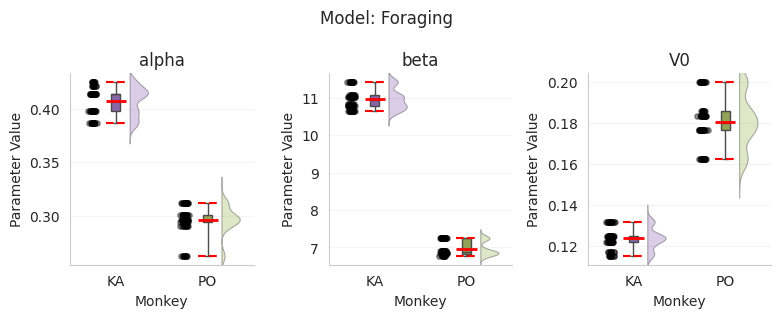

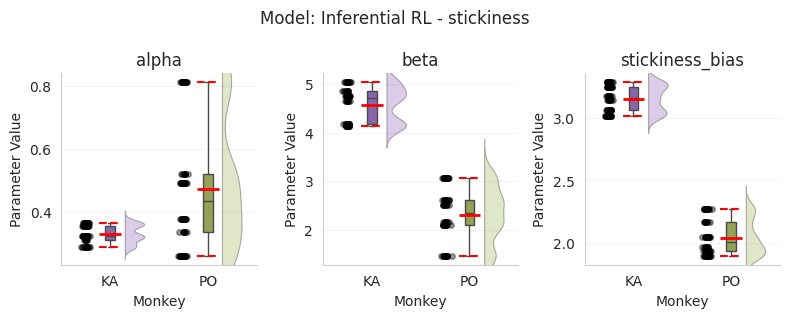

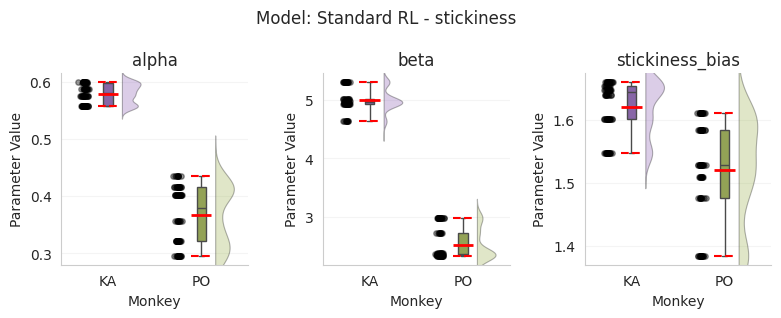

Created 3 figures for models: ['Foraging', 'Inferential RL - stickiness', 'Standard RL - stickiness']


In [5]:
# Get unique models and their parameters
models = plot_df["model"].unique()

# Create color dictionary for monkeys
color_dict = {"KA": COLORS["ka"], "PO": COLORS["po"]}

# Create a figure for each model
figures = {}
for model_idx, model in enumerate(models):
    model_data = plot_df[plot_df["model"] == model]
    params_in_model = model_data["parameter"].unique()
    
    # Calculate number of subplots needed
    n_params = len(params_in_model)
    n_cols = 3
    n_rows = (n_params + n_cols - 1) // n_cols
    
    # Create figure with smaller size
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 3.2 * n_rows))
    
    # Ensure axes is always 2D array
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1 or n_cols == 1:
        axes = axes.reshape(n_rows, n_cols)
    
    # Create a raincloud plot for each parameter
    for param_idx, param in enumerate(params_in_model):
        row = param_idx // n_cols
        col = param_idx % n_cols
        ax = axes[row, col]
        
        param_data = model_data[model_data["parameter"] == param]
        create_raincloud_plot(param_data, ax, param, color_dict)
    
    # Hide unused subplots
    for param_idx in range(n_params, n_rows * n_cols):
        row = param_idx // n_cols
        col = param_idx % n_cols
        axes[row, col].set_visible(False)

    # despine 
    sns.despine(fig=fig)

    fig.suptitle(f"Model: {model}")
    plt.tight_layout()
    figures[model] = fig
    plt.show()
    
print(f"Created {len(figures)} figures for models: {list(figures.keys())}")